# Este es el csv de customer.churn con los datos crudos 

In [1]:
import pandas as pd

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Para machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

# Configuración de visualización
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [4]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [3]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
df['customerID'][0]

'7590-VHVEG'

In [16]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

## VER MI DATA SET 
## int64 es variable numerica
## object es variable tipo categorico pero
## Generalmente, Pandas usa object para guardar texto (lo mismo que str),
## pero también lo usa cuando una columna tiene una mezcla de números, letras y símbolos 
## que no logra identificar como un número puro.
## str es variable con cadenas de texto, letras o palabras.
## float 64 es variable numerica pero con decimales 

# Contexto del Negocio

## Una empresa de telecomunicaciones ofrece servicios de internet, telefonía y cable.  
## El problema actual es la fuga de clientes (Churn).  
## El objetivo de este análisis es identificar patrones en los clientes que se van,  
## utilizando información demográfica, tipo de contrato y cargos mensuales,  
## para predecir quién es más probable que cancele el servicio y así poder  
## ofrecerle incentivos (como descuentos) antes de que se vaya.

In [17]:
# Muestra información general: cantidad de filas, columnas y tipos de datos
print("--- RADIOGRAFÍA DEL DATASET ---")
df.info()

# Si solo quieres ver la lista limpia de los nombres de tus columnas:
# print(df.columns.tolist())

--- RADIOGRAFÍA DEL DATASET ---
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  704

## En este resultado se pude analizar que todas las columnas tienen la misma cantidad de datos 

In [15]:
df.iloc[0]

customerID                7590-VHVEG
gender                        Female
SeniorCitizen                      0
Partner                          Yes
Dependents                        No
tenure                             1
PhoneService                      No
MultipleLines       No phone service
InternetService                  DSL
OnlineSecurity                    No
OnlineBackup                     Yes
DeviceProtection                  No
TechSupport                       No
StreamingTV                       No
StreamingMovies                   No
Contract              Month-to-month
PaperlessBilling                 Yes
PaymentMethod       Electronic check
MonthlyCharges                 29.85
TotalCharges                   29.85
Churn                             No
Name: 0, dtype: object

--- COLUMNAS CON DATOS FALTANTES ---


,Nulos Totales,Porcentaje (%)
TotalCharges,11,0.16


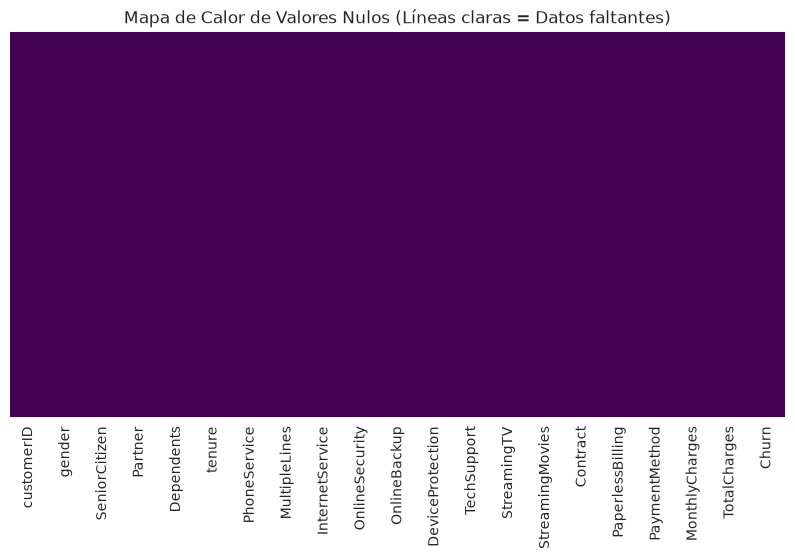

In [18]:
# ==========================================
# 1. REPORTE NUMÉRICO Y VISUAL DE NULOS
# ==========================================

# IMPORTANTE: Forzamos primero a que los espacios en blanco de TotalCharges se vuelvan nulos reales (NaN)
# (Si ya lo corriste antes, no hay problema en volver a correrlo)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# --- PARTE A: El Reporte Matemático ---
nulos = df.isnull().sum()
porcentaje = round((nulos / len(df)) * 100, 2)

# Creamos una mini tabla para verlo ordenado
tabla_nulos = pd.DataFrame({'Nulos Totales': nulos, 'Porcentaje (%)': porcentaje})

print("--- COLUMNAS CON DATOS FALTANTES ---")
# Filtramos para mostrar SOLO las columnas que tienen problemas
display(tabla_nulos[tabla_nulos['Nulos Totales'] > 0])

# --- PARTE B: El Mapa de Calor (Visualización) ---
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
# Este gráfico pintará de un color distinto cada celda vacía de tu tabla
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Mapa de Calor de Valores Nulos (Líneas claras = Datos faltantes)')
plt.show()

## "Menos del 5% -> Borrar las filas" la decision es borrar los datos faltantes 
## por eso en el grafico no se puede visualizar nada ya que el porcentaje es 
## bastante menor al 5% para poder verlo 

In [32]:
# ==========================================
# ELIMINACIÓN DE NULOS Y DUPLICADOS REZAGADOS
# ==========================================

# 1. Eliminamos las 11 filas con nulos en TotalCharges
df = df.dropna()
print("✅ Nulos eliminados.")

# 2. Buscamos y eliminamos filas clonadas (por seguridad)
duplicados = df.duplicated().sum()
if duplicados > 0:
    df = df.drop_duplicates()
    print(f"✅ Se eliminaron {duplicados} filas duplicadas.")
else:
    print("✅ No se encontraron filas duplicadas.")

print("-" * 30)
print(f"Tamaño final y definitivo del dataset: {df.shape[0]} filas y {df.shape[1]} columnas.")

✅ Nulos eliminados.
✅ Se eliminaron 22 filas duplicadas.
------------------------------
Tamaño final y definitivo del dataset: 7010 filas y 20 columnas.


In [19]:
# ==========================================
# REPORTE PARA DETECTAR COLUMNAS IRRELEVANTES
# ==========================================

print(f"Total de filas en el dataset: {len(df)}\n")

# Creamos una tabla que nos muestre los tipos de datos y cuántos valores únicos tiene cada columna
auditoria = pd.DataFrame({
    'Tipo de Dato': df.dtypes,
    'Valores Únicos': df.nunique(),
    'Ejemplo de Dato': df.iloc[0] # Te muestra qué aspecto tiene el dato
})

# Ordenamos la tabla de mayor a menor cantidad de valores únicos
display(auditoria.sort_values(by='Valores Únicos', ascending=False))

Total de filas en el dataset: 7043



,Tipo de Dato,Valores Únicos,Ejemplo de Dato
customerID,str,7043,7590-VHVEG
TotalCharges,float64,6530,29.85
MonthlyCharges,float64,1585,29.85
tenure,int64,73,1
PaymentMethod,str,4,Electronic check
StreamingMovies,str,3,No
TechSupport,str,3,No
OnlineBackup,str,3,Yes
StreamingTV,str,3,No
DeviceProtection,str,3,No


## En este caso debo ELIMINAR CUSTOMER ID
## VISUALIZAR SeniorCitizen,Dependents 
## Como ambas variables (SeniorCitizen y Dependents) son demográficas y 
## categóricas (son grupos de personas, no rangos de precios), la mejor forma de visualizarlas 
## es con gráficos de barras (Countplots)

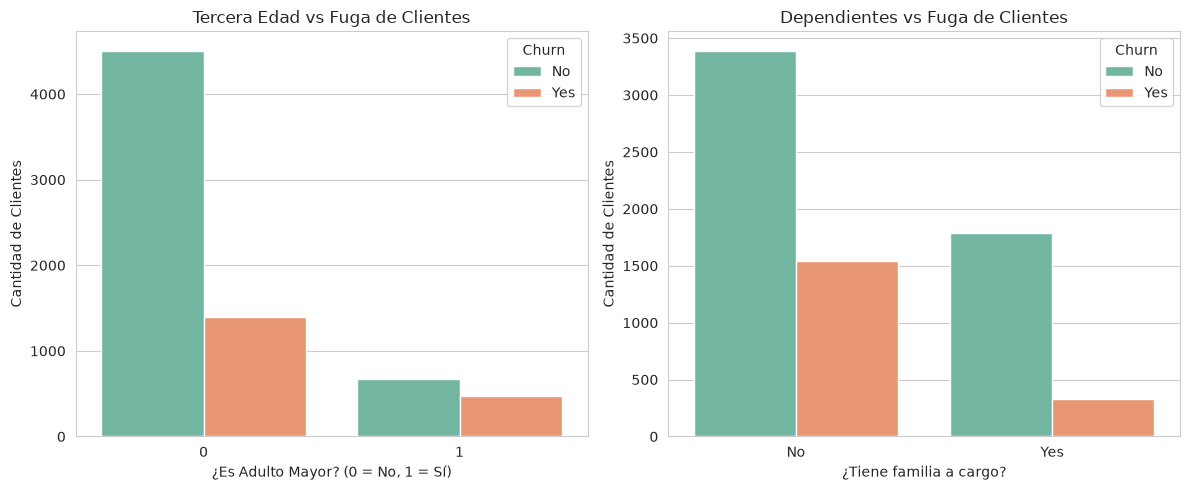

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creamos una figura con dos espacios (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- GRÁFICO 1: SeniorCitizen (Tercera Edad) ---
# Recuerda que aquí el 0 significa "No" y el 1 significa "Sí"
sns.countplot(data=df, x='SeniorCitizen', hue='Churn', palette='Set2', ax=axes[0])
axes[0].set_title('Tercera Edad vs Fuga de Clientes')
axes[0].set_xlabel('¿Es Adulto Mayor? (0 = No, 1 = Sí)')
axes[0].set_ylabel('Cantidad de Clientes')

# --- GRÁFICO 2: Dependents (Personas a cargo/Hijos) ---
sns.countplot(data=df, x='Dependents', hue='Churn', palette='Set2', ax=axes[1])
axes[1].set_title('Dependientes vs Fuga de Clientes')
axes[1].set_xlabel('¿Tiene familia a cargo?')
axes[1].set_ylabel('Cantidad de Clientes')

plt.tight_layout()
plt.show()

## El problema que se puede analizar en el primer grafico 
## Les cuesta muy caro o no aprovechan el plan los adultdos mayores.
## CONCLUSION DE NEGOCIO:Probablemente les están vendiendo planes de Fibra Óptica de 1000 Megas 
## cuando ellos solo usan internet para WhatsApp o leer noticias. Se dan cuenta de que es un desperdicio de dinero y cancelan.

## En el grafico 2
## Las familias aprovechan a tope el internet, pero el soltero quizás está pagando lo mismo 
## por un plan familiar que no necesita, y la empresa no tiene un plan adaptado para él.
## CONCLUSION DE NEGOCIO:Las familias actúan como un "ancla" (si los niños ven Netflix y 
## los papás teletrabajan, es imposible cortar el internet). 
## El soltero, en cambio, si siente que paga mucho, simplemente lo cancela y usa el 5G de su celular. 

## AHORA 
## Para comprobar si los solteros están pagando lo mismo que las familias y por eso se van, 
## necesitamos cruzar tres variables al mismo tiempo: Dependents, MonthlyCharges (Dinero) y Churn.

In [21]:
# ==========================================
# BÚSQUEDA Y LIMPIEZA DE FILAS DUPLICADAS
# ==========================================

# 1. Contar cuántos clones exactos hay en tu base de datos
total_duplicados = df.duplicated().sum()
print(f"Total de filas duplicadas encontradas: {total_duplicados}\n")

# 2. Verlos cara a cara (Solo se ejecuta si encuentra duplicados)
if total_duplicados > 0:
    print("Mostrando las filas repetidas:")
    # keep=False le dice a Pandas que te muestre en pantalla tanto el original como la copia
    display(df[df.duplicated(keep=False)])
    
    # 3. Eliminar los clones (Pandas guarda la primera aparición y borra el resto)
    df = df.drop_duplicates()
    print("\n✅ ¡Duplicados eliminados con éxito!")
else:
    print("✅ Tu base de datos está sana, no hay clones.")

Total de filas duplicadas encontradas: 0

✅ Tu base de datos está sana, no hay clones.


## A veces, los datos no son nulos ni están duplicados, pero están sucios por dentro. 
## Ocurre cuando un humano (o un sistema mal configurado) ingresa el mismo concepto con 
## distintos nombres.

## Ejemplo: En una columna de género podrías tener ['Male', 'Female', 'male', 'F']. 
## Para ti es lo mismo, pero para el modelo matemático son 4 categorías completamente distintas.

In [22]:
# ==========================================
# 1. ELIMINACIÓN SEGURA DEL ID
# ==========================================
# Como ya comprobamos que no hay duplicados, lo borramos sin miedo
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)
    print("✅ Columna 'customerID' eliminada con seguridad.\n")

# ==========================================
# 2. AUDITORÍA DE ERRORES TIPOGRÁFICOS
# ==========================================
print("--- VALORES ÚNICOS EN COLUMNAS DE TEXTO ---")

# Seleccionamos solo las columnas que son de tipo texto ('object')
columnas_texto = df.select_dtypes(include=['object']).columns

# Hacemos un ciclo para imprimir las opciones de cada columna
for col in columnas_texto:
    valores_unicos = df[col].unique()
    print(f"[{col}]: {valores_unicos}")

✅ Columna 'customerID' eliminada con seguridad.

--- VALORES ÚNICOS EN COLUMNAS DE TEXTO ---
[gender]: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
[Partner]: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
[Dependents]: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
[PhoneService]: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
[MultipleLines]: <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
[InternetService]: <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
[OnlineSecurity]: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
[OnlineBackup]: <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
[DeviceProtection]: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
[TechSupport]: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
[StreamingTV]: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
[StreamingMovies]: <StringArray

/tmp/ipykernel_8299/2815422573.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_texto = df.select_dtypes(include=['object']).columns


## la "basura silenciosa" se agrupa en dos grandes problemas de redundancia que van a confundir a tu modelo matemático
## El problema del Teléfono,El problema del Internet,

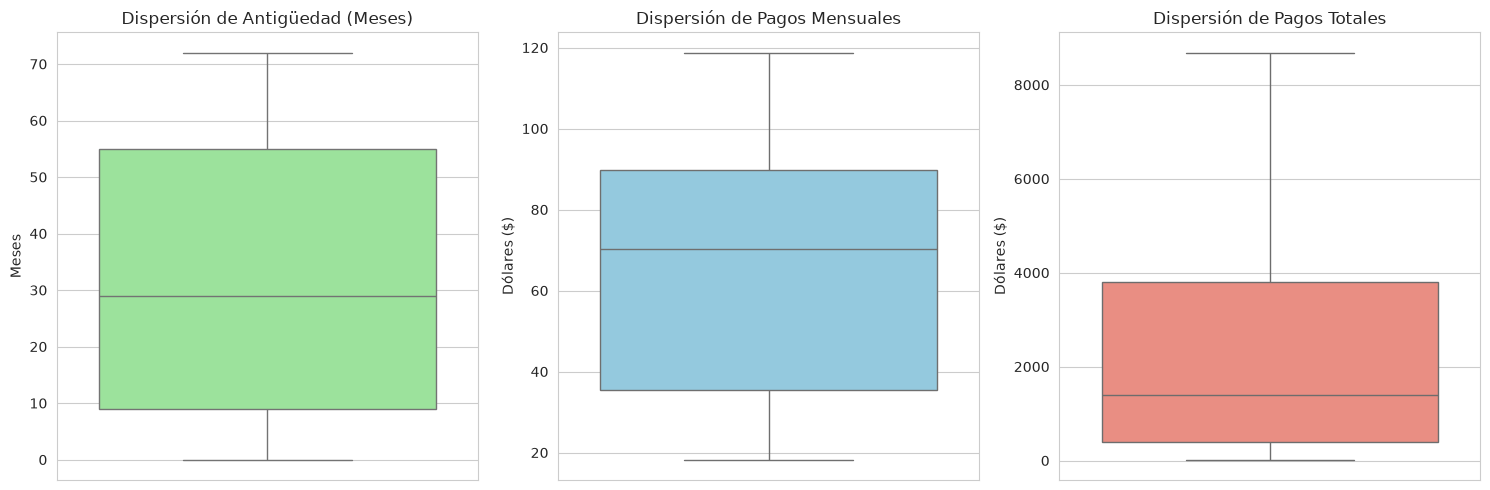

In [23]:
# ==========================================
# BÚSQUEDA VISUAL DE VALORES EXTREMOS (OUTLIERS)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# Creamos un lienzo con 3 espacios (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Gráfico de Antigüedad
sns.boxplot(data=df, y='tenure', color='lightgreen', ax=axes[0])
axes[0].set_title('Dispersión de Antigüedad (Meses)')
axes[0].set_ylabel('Meses')

# 2. Gráfico de Cargos Mensuales
sns.boxplot(data=df, y='MonthlyCharges', color='skyblue', ax=axes[1])
axes[1].set_title('Dispersión de Pagos Mensuales')
axes[1].set_ylabel('Dólares ($)')

# 3. Gráfico de Cargos Totales
sns.boxplot(data=df, y='TotalCharges', color='salmon', ax=axes[2])
axes[2].set_title('Dispersión de Pagos Totales')
axes[2].set_ylabel('Dólares ($)')

# Ajustamos el espacio y mostramos
plt.tight_layout()
plt.show()

## DISPERSIONDE PAGOS TOTALES:es demasiada grande quizas los que estan llegando a los 2000 son companias.
## hay otra explicación más común. Hay que recordar la fórmula matemática del negocio: Pago Total = Pago Mensual × Antigüedad.
## Un cliente residencial normal (una familia) puede contratar un plan premium: Fibra óptica de alta velocidad + Televisión por cable + 2 líneas de teléfono. 
## Eso suma fácilmente unos $100 dólares mensuales. Si esa familia es un "cliente confiable" y se queda 5 años (60 meses) en la compañía, su Pago Total será de $6,000 dólares.

## lo bueno de esta empresa que la dispersion de antiguedad es de clientes confiables la gran mayoria 

## dispersion de pagos mensuales: La mayoria de pagos son entre 75 doleres a 35 dolares aprox, se podria decir que mayor a 75 dolares deben ser empresas contrando el servicio 

## Como observacion general no hay outliers extremos 

In [24]:
# ==========================================
# AUDITORÍA DE ERRORES TIPOGRÁFICOS EN TEXTOS
# ==========================================

# 1. Filtramos para trabajar SOLO con las columnas de texto (categóricas)
columnas_texto = df.select_dtypes(include=['object']).columns

print("🔍 INICIANDO BÚSQUEDA DE CATEGORÍAS 🔍\n")

# 2. Creamos un bucle que recorrerá cada columna y nos mostrará sus opciones
for col in columnas_texto:
    print(f"📌 Columna: {col}")
    # value_counts() muestra los nombres exactos de las categorías y cuánta gente hay en cada una
    print(df[col].value_counts())
    print("-" * 40)

🔍 INICIANDO BÚSQUEDA DE CATEGORÍAS 🔍

📌 Columna: gender
gender
Male      3555
Female    3488
Name: count, dtype: int64
----------------------------------------
📌 Columna: Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64
----------------------------------------
📌 Columna: Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
----------------------------------------
📌 Columna: PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
----------------------------------------
📌 Columna: MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
----------------------------------------
📌 Columna: InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
----------------------------------------
📌 Columna: OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service   

/tmp/ipykernel_8299/158444684.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_texto = df.select_dtypes(include=['object']).columns


## La buena noticia: No tienes errores de tipeo horribles. No hay "Female", "female" y "F". La base de datos fue ingresada por un sistema automático, no tipeada a mano por un humano.

## La mala noticia (El problema de la redundancia):
## la categoría No internet service se repite exactamente 1526 veces en seis columnas distintas (Soporte técnico, Seguridad, TV, etc.). 
## Ese número no es casualidad; si miras la columna InternetService, verás que hay exactamente 1526 personas que dijeron que "No" tienen internet.

## Por qué esto es malo para el modelo matemático: Para un algoritmo, "No" es el valor 0, y "Yes" es el valor 1. Si dejas la frase "No internet service", 
## el modelo creerá que es un servicio extra (un valor 2) y se va a confundir terriblemente. Si alguien no tiene internet, por defecto lógica no tiene soporte técnico de internet. 
## La respuesta correcta debe ser simplemente "No".

## Lo mismo pasa en la columna MultipleLines con el mensaje No phone service (682 veces).


In [25]:
# ==========================================
# UNIFICACIÓN DE CATEGORÍAS REDUNDANTES
# ==========================================

# 1. Arreglamos las columnas dependientes del internet
columnas_internet = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                     'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in columnas_internet:
    # Reemplazamos la frase larga simplemente por un 'No'
    df[col] = df[col].replace({'No internet service': 'No'})

# 2. Arreglamos la columna dependiente del teléfono
df['MultipleLines'] = df['MultipleLines'].replace({'No phone service': 'No'})

print("✅ Redundancias eliminadas con éxito.")

# Comprobamos rápidamente que haya funcionado en una de las columnas
print("\nAsí quedó TechSupport ahora:")
print(df['TechSupport'].value_counts())

✅ Redundancias eliminadas con éxito.

Así quedó TechSupport ahora:
TechSupport
No     4999
Yes    2044
Name: count, dtype: int64


In [26]:
# ==========================================
# DETECCIÓN DE "FALSO TEXTO" (Tipos de datos)
# ==========================================

# Creamos una tabla comparativa para auditar los datos
auditoria_tipos = pd.DataFrame({
    'Tipo de Dato (Pandas)': df.dtypes,
    'Primer Valor (Visual)': df.iloc[0], # Vemos el primer dato real
    'Tercer Valor (Visual)': df.iloc[2]  # Vemos otro dato para confirmar
})

print("🔍 RADIOGRAFÍA DE TIPOS DE DATOS 🔍")
display(auditoria_tipos)

🔍 RADIOGRAFÍA DE TIPOS DE DATOS 🔍


,Tipo de Dato (Pandas),Primer Valor (Visual),Tercer Valor (Visual)
gender,str,Female,Male
SeniorCitizen,int64,0,0
Partner,str,Yes,No
Dependents,str,No,No
tenure,int64,1,2
PhoneService,str,No,Yes
MultipleLines,str,No,No
InternetService,str,DSL,DSL
OnlineSecurity,str,No,Yes
OnlineBackup,str,Yes,Yes


# la radiografía de una base de datos sana y limpia.

In [27]:
# ==========================================
# ESCÁNER DE ESPACIOS EN BLANCO OCULTOS
# ==========================================

# Seleccionamos las columnas de texto (usando 'object' y 'str' para evitar el Warning)
columnas_texto = df.select_dtypes(include=['object', 'str']).columns

print("🔍 INICIANDO ESCÁNER DE ESPACIOS OCULTOS 🔍\n")
espacios_encontrados = False

for col in columnas_texto:
    # Comparamos el texto original vs el texto pasándole la función .strip() (que borra espacios laterales)
    # Si no son iguales, significa que había un espacio escondido.
    filas_con_espacios = df[df[col] != df[col].str.strip()]
    
    if not filas_con_espacios.empty:
        espacios_encontrados = True
        print(f"⚠️ ¡Alerta! Se encontraron espacios ocultos en la columna: '{col}'")
        
        # Mostramos los valores exactos, usando corchetes para hacer visible el espacio
        valores_sucios = filas_con_espacios[col].unique()
        for valor in valores_sucios:
            print(f"   -> Así lo ve el computador: [{valor}]")
        print("-" * 40)

if not espacios_encontrados:
    print("✅ Escáner finalizado: ¡Tu base de datos está impecable! No hay espacios laterales ocultos.")

🔍 INICIANDO ESCÁNER DE ESPACIOS OCULTOS 🔍

✅ Escáner finalizado: ¡Tu base de datos está impecable! No hay espacios laterales ocultos.


In [28]:
# ==========================================
# ESCÁNER DE INCONSISTENCIAS DE FORMATO (MAYÚSCULAS)
# ==========================================

columnas_texto = df.select_dtypes(include=['object', 'str']).columns

print("🔍 INICIANDO BÚSQUEDA DE INCONSISTENCIAS DE FORMATO 🔍\n")
inconsistencias_encontradas = False

for col in columnas_texto:
    # Contamos cuántas categorías únicas hay originalmente
    unicos_original = df[col].nunique()
    
    # Contamos cuántas categorías quedan si pasamos todo a minúsculas
    unicos_minuscula = df[col].str.lower().nunique()
    
    # Si el número baja, significa que había palabras escritas con distintas mayúsculas
    if unicos_original > unicos_minuscula:
        inconsistencias_encontradas = True
        print(f"⚠️ ¡Alerta! Se encontraron inconsistencias en la columna: '{col}'")
        print(f"   -> Categorías originales ({unicos_original}): {df[col].unique()}")
        print(f"   -> Si unificamos a minúsculas bajaría a ({unicos_minuscula}) categorías.")
        print("-" * 40)

if not inconsistencias_encontradas:
    print("✅ Escáner finalizado: No hay inconsistencias de formato. Todas las mayúsculas/minúsculas están estandarizadas.")

🔍 INICIANDO BÚSQUEDA DE INCONSISTENCIAS DE FORMATO 🔍

✅ Escáner finalizado: No hay inconsistencias de formato. Todas las mayúsculas/minúsculas están estandarizadas.


In [29]:
# ==========================================
# ESCÁNER DE LÓGICA DE NEGOCIO (CONTRADICCIONES)
# ==========================================

print("🔍 INICIANDO AUDITORÍA DE LÓGICA DE NEGOCIO 🔍\n")

# Regla 1: Sin teléfono, pero con múltiples líneas
error_telefono = df[(df['PhoneService'] == 'No') & (df['MultipleLines'] == 'Yes')]

# Regla 2: Sin internet, pero con servicios web activos
error_internet = df[(df['InternetService'] == 'No') & 
                    ((df['StreamingTV'] == 'Yes') | (df['OnlineSecurity'] == 'Yes'))]

# Regla 3: Pago Total menor al Pago Mensual (Matemáticamente imposible)
error_pagos = df[df['TotalCharges'] < df['MonthlyCharges']]

# Imprimimos el reporte
print(f"⚠️ Sin teléfono, pero con múltiples líneas: {len(error_telefono)} casos")
print(f"⚠️ Sin internet, pero con streaming/seguridad: {len(error_internet)} casos")
print(f"⚠️ Pago Total menor al Pago Mensual: {len(error_pagos)} casos")
print("-" * 40)

# Evaluación final
total_errores = len(error_telefono) + len(error_internet) + len(error_pagos)

if total_errores == 0:
    print("✅ Escáner finalizado: ¡Lógica de negocio impecable! No hay contradicciones.")
else:
    print("❌ Se encontraron contradicciones lógicas que ensucian el dataset.")

🔍 INICIANDO AUDITORÍA DE LÓGICA DE NEGOCIO 🔍

⚠️ Sin teléfono, pero con múltiples líneas: 0 casos
⚠️ Sin internet, pero con streaming/seguridad: 0 casos
⚠️ Pago Total menor al Pago Mensual: 0 casos
----------------------------------------
✅ Escáner finalizado: ¡Lógica de negocio impecable! No hay contradicciones.


In [30]:
# ==========================================
# ESCÁNER DE CATEGORÍAS MINORITARIAS (RARE LABELS)
# ==========================================

columnas_texto = df.select_dtypes(include=['object', 'str']).columns
umbral = 0.05 # 5% de representación mínima requerida
total_filas = len(df)

print("🔍 INICIANDO BÚSQUEDA DE CATEGORÍAS MINORITARIAS (< 5%) 🔍\n")
rare_labels_encontrados = False

for col in columnas_texto:
    # normalize=True calcula directamente el porcentaje (del 0 al 1)
    porcentajes = df[col].value_counts(normalize=True)
    
    # Filtramos las categorías que están por debajo del umbral del 0.05 (5%)
    categorias_raras = porcentajes[porcentajes < umbral]
    
    if not categorias_raras.empty:
        rare_labels_encontrados = True
        print(f"⚠️ ¡Alerta! Categorías minoritarias en la columna: '{col}'")
        for cat, pct in categorias_raras.items():
            cantidad = int(pct * total_filas)
            print(f"   -> [{cat}]: Representa solo el {pct*100:.2f}% ({cantidad} clientes)")
        print("-" * 40)

if not rare_labels_encontrados:
    print("✅ Escáner finalizado: No hay rare labels. Todas las categorías tienen un peso estadístico sano (>5%).")

🔍 INICIANDO BÚSQUEDA DE CATEGORÍAS MINORITARIAS (< 5%) 🔍

✅ Escáner finalizado: No hay rare labels. Todas las categorías tienen un peso estadístico sano (>5%).


In [31]:
# ==========================================
# ESCÁNER DE UNIDADES DE MEDIDA Y SÍMBOLOS
# ==========================================
import pandas as pd

print("🔍 INICIANDO BÚSQUEDA DE NÚMEROS MEZCLADOS EN TEXTO 🔍\n")
unidades_encontradas = False

columnas_texto = df.select_dtypes(include=['object', 'str']).columns

for col in columnas_texto:
    # Usamos regex (r'\d') para buscar si existe algún dígito (0-9) escondido dentro del texto
    contiene_numeros = df[col].astype(str).str.contains(r'\d', regex=True)
    
    # Si encuentra al menos una fila que cumpla esta condición, levanta la alerta
    if contiene_numeros.any():
        unidades_encontradas = True
        print(f"⚠️ ¡Alerta! Se detectaron números o unidades en la columna categórica: '{col}'")
        
        # Mostramos los primeros 5 ejemplos distintos para que puedas ver de qué se trata
        ejemplos = df[df[col].astype(str).str.contains(r'\d', regex=True)][col].unique()[:5]
        print(f"   -> Ejemplos visuales: {ejemplos}")
        print("-" * 40)

if not unidades_encontradas:
    print("✅ Escáner finalizado: No hay unidades de medida mezcladas. El texto es 100% texto y los números son números.")

🔍 INICIANDO BÚSQUEDA DE NÚMEROS MEZCLADOS EN TEXTO 🔍

✅ Escáner finalizado: No hay unidades de medida mezcladas. El texto es 100% texto y los números son números.


In [34]:
# ==========================================
# MÁQUINA DEL TIEMPO: VISUALIZAR LO ELIMINADO
# ==========================================
import pandas as pd
#('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# 1. Cargamos el archivo original de nuevo, pero en una variable temporal (para no dañar tu df limpio)
df_original = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Recreamos el problema numérico para poder ver los nulos
df_original['TotalCharges'] = pd.to_numeric(df_original['TotalCharges'], errors='coerce')

# 2. Rescatamos las 11 filas con nulos
filas_nulas = df_original[df_original['TotalCharges'].isnull()]

# 3. Rescatamos los duplicados. 
# (Recuerda que los duplicados aparecieron después de borrar el customerID, así que lo borramos temporalmente aquí)
df_temp_sin_id = df_original.drop('customerID', axis=1)
# keep=False nos permite ver tanto la fila original como su clon exacto
filas_duplicadas = df_original[df_temp_sin_id.duplicated(keep=False)]

print("🔍 RADIOGRAFÍA DE LAS FILAS ELIMINADAS 🔍\n")

print(f"--- LAS {len(filas_nulas)} FILAS CON NULOS EN TOTAL CHARGES ---")
display(filas_nulas)

print(f"\n--- LAS FILAS DUPLICADAS (Total: {len(filas_duplicadas)} filas contando los clones) ---")
# Ordenamos por una columna para que los clones queden uno debajo del otro y puedas compararlos con tus ojos
display(filas_duplicadas.sort_values(by='MonthlyCharges').head(6))

🔍 RADIOGRAFÍA DE LAS FILAS ELIMINADAS 🔍

--- LAS 11 FILAS CON NULOS EN TOTAL CHARGES ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No



--- LAS FILAS DUPLICADAS (Total: 42 filas contando los clones) ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
542,2866-IKBTM,Female,0,No,No,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
1491,8605-ITULD,Female,0,No,No,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
5170,7721-DVEKZ,Female,0,No,No,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.65,19.65,No
6774,0970-QXPXW,Female,0,No,No,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.65,19.65,No
6706,7878-RTCZG,Female,0,No,No,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.90,19.90,No
4817,6654-QGBZZ,Female,0,No,No,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.90,19.90,No


In [35]:
df.to_csv('datos_limpios.csv', index=False)

## Desde aca el base de datos crudo fue limpiada y con el nombre: datos_limpios.csv, ahora se ejecuta desde aqui hacia abajo para seguir con el analisis de datos 

In [1]:
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y validación
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix

# Modelos de Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Carga de datos
# ==========================================
df = pd.read_csv('datos_limpios.csv')

In [2]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# 1. Cargamos tu archivo de ayer (ajusta el nombre si le pusiste 'datos_limpios.csv')
df = pd.read_csv('datos_limpios.csv')

# 2. Convertimos la variable objetivo 'Churn' (Nuestra meta) a 1 y 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 3. Convertimos variables binarias simples (Yes/No a 1/0)
binarias = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binarias:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# 4. Convertimos el Género
df['gender'] = df['gender'].map({'Female': 1, 'Male': 0})

print("✅ Variables binarias convertidas exitosamente a 0 y 1.")
display(df[['gender', 'Partner', 'Churn']].head(3))

✅ Variables binarias convertidas exitosamente a 0 y 1.


,gender,Partner,Churn
0,1,1,0
1,0,0,0
2,0,0,1


In [3]:
# ==========================================
# PASO 2: ONE-HOT ENCODING (Múltiples opciones)
# ==========================================

# get_dummies transforma automáticamente el texto restante en columnas separadas.
# 'drop_first=True' es un truco para evitar redundancia (si no es fibra ni DSL, el modelo deduce que es 'No')
df = pd.get_dummies(df, drop_first=True)

# Convertimos los valores booleanos (True/False) que arroja pandas a números enteros (1/0)
df = df.astype(int, errors='ignore') 

print(f"✅ One-Hot Encoding completado.")
print(f"📊 Tu tabla pasó de 20 columnas a tener {df.shape[1]} columnas numéricas.")
display(df.head(3))

✅ One-Hot Encoding completado.
📊 Tu tabla pasó de 20 columnas a tener 24 columnas numéricas.


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,1,29,29,0,...,1,0,0,0,0,0,0,0,1,0
1,0,0,0,0,34,1,0,56,1889,0,...,0,1,0,0,0,1,0,0,0,1
2,0,0,0,0,2,1,1,53,108,1,...,1,0,0,0,0,0,0,0,0,1


In [4]:
# ==========================================
# PASO 3: ESCALADO NUMÉRICO (Scaling)
# ==========================================
# Tus columnas de dinero y antigüedad tienen números grandes (ej. 1500 USD).
# El algoritmo puede creer erróneamente que "más grande = más importante".
# MinMaxScaler "aplasta" todos esos números a un rango de 0 a 1.

scaler = MinMaxScaler()
columnas_numericas = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Ajustamos y transformamos las columnas
df[columnas_numericas] = scaler.fit_transform(df[columnas_numericas])

print("✅ PASO 3: Variables numéricas escaladas perfectamente (rango 0-1).")

# ==========================================
# PASO 4: DIVIDIR DATOS (Train / Test) Y GUARDAR
# ==========================================
# Separamos la 'X' (Características de los clientes) y la 'y' (La meta a predecir: Churn)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Dividimos el curso: 80% para enseñar a la IA, 20% para tomarle un examen final
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"📊 Entrenamiento (Train): {X_train.shape[0]} clientes listos para enseñar.")
print(f"📊 Prueba (Test): {X_test.shape[0]} clientes listos para evaluar.")

# Guardamos los 4 pedazos de datos procesados en el disco duro
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print("\n🚀 ¡DÍA 3 COMPLETADO! Todos los archivos están exportados.")

✅ PASO 3: Variables numéricas escaladas perfectamente (rango 0-1).
📊 Entrenamiento (Train): 5608 clientes listos para enseñar.
📊 Prueba (Test): 1402 clientes listos para evaluar.

🚀 ¡DÍA 3 COMPLETADO! Todos los archivos están exportados.


## 1. REGRESIÓN LOGÍSTICA (El Modelo Base)


🚀 Cargando datos e iniciando entrenamiento...

--- RESULTADOS REGRESIÓN LOGÍSTICA ---
Exactitud (Accuracy): 74.04%
Precisión (Precision): 46.17%
Sensibilidad (Recall): 80.69%


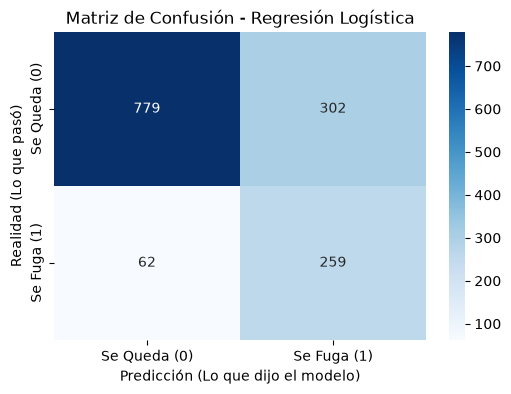

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix

print("🚀 Cargando datos e iniciando entrenamiento...")

# 1. Cargamos los datos procesados del Día 3
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
# Usamos .squeeze() para que pandas lea la 'y' como una lista simple (Serie) y no como una tabla, evitando advertencias
y_train = pd.read_csv('y_train.csv').squeeze() 
y_test = pd.read_csv('y_test.csv').squeeze()

# 2. Inicializamos el modelo 
# EL SECRETO PRO: class_weight='balanced' obliga al modelo a prestarle atención a los que se fugan
modelo_logistico = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# 3. Entrenamiento (El modelo lee el libro)
modelo_logistico.fit(X_train, y_train)

# 4. Predicción (El modelo rinde el examen)
y_pred_log = modelo_logistico.predict(X_test)

# 5. Evaluación (Calculamos la nota)
print("\n--- RESULTADOS REGRESIÓN LOGÍSTICA ---")
print(f"Exactitud (Accuracy): {accuracy_score(y_test, y_pred_log):.2%}")
print(f"Precisión (Precision): {precision_score(y_test, y_pred_log):.2%}")
print(f"Sensibilidad (Recall): {recall_score(y_test, y_pred_log):.2%}")

# 6. Gráfico: Matriz de Confusión
matriz = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(6, 4))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Se Queda (0)', 'Se Fuga (1)'], 
            yticklabels=['Se Queda (0)', 'Se Fuga (1)'])
plt.ylabel('Realidad (Lo que pasó)')
plt.xlabel('Predicción (Lo que dijo el modelo)')
plt.title('Matriz de Confusión - Regresión Logística')
plt.show()

## 302 (Cuadrado superior derecho - Falsos Positivos): El "costo" de tu modelo. El algoritmo se puso un poco paranoico y  etiquetó a 302 clientes leales como "fugitivos". Si la empresa les ofrece un descuento para retenerlos, estaría perdiendo un poco de dinero porque ellos no se iban a ir de todas formas. (Por esto tu Precisión es del 46.17%, el modelo dispara un poco a ciegas por el miedo a que se le escape alguien).

## 259 (Cuadrado inferior derecho - Verdaderos Positivos): ¡Los clientes salvados! Son 259 personas que se iban a fugar, el modelo los detectó, y ahora el equipo de ventas puede llamarlos para ofrecerles una promoción y retenerlos.

## 779 (Cuadrado superior izquierdo - Verdaderos Negativos): Clientes felices que el modelo ignoró correctamente.

## 62 (Cuadrado inferior izquierdo - Falsos Negativos): Las fugas sorpresa. Son clientes que el modelo pensó que estaban felices (Se Queda), pero en realidad se fueron. Solo se te escaparon 62. Mantener este número bajo es tu mayor victoria.

## Un modelo altamente protector. Prefiere asustarse de más (los 302 falsos positivos) con tal de asegurarse de que casi ningún cliente real 
## se escape (atrapó a 259 y solo perdió 62). En muchas empresas de telecomunicaciones, prefieren exactamente esto: gastar un poco de dinero en 
## descuentos innecesarios es mejor que perder clientes para siempre.

## Ahora pondremos a prueba al Random Forest (Bosque Aleatorio). Este algoritmo no trazará una sola línea matemática, sino que construirá 
## 100 "árboles de decisión" distintos, los pondrá a evaluar a tus clientes y hará que voten para decidir quién se fuga.

## 2. RANDOM FOREST (El Bosque Aleatorio)


🌲 Plantando el bosque e iniciando entrenamiento...

--- RESULTADOS RANDOM FOREST ---
Exactitud (Accuracy): 77.39%
Precisión (Precision): 50.47%
Sensibilidad (Recall): 67.29%


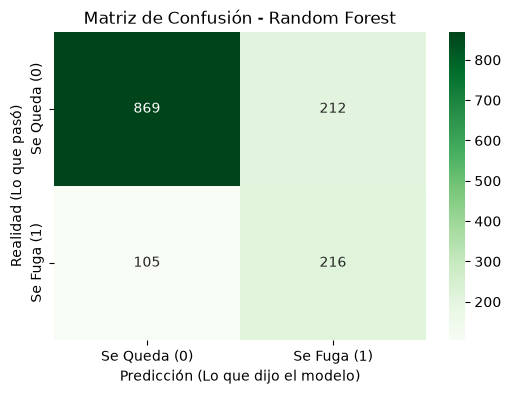

In [7]:
from sklearn.ensemble import RandomForestClassifier

print("🌲 Plantando el bosque e iniciando entrenamiento...")

# 1. Inicializamos el modelo (mantenemos class_weight='balanced' para enfocarnos en el Recall)
# n_estimators=100 significa que crearemos 100 árboles de decisión para votar
modelo_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# 2. Entrenamiento real del Random Forest
modelo_rf.fit(X_train, y_train)

# 3. Predicción (¡Creamos la nueva variable y_pred_rf!)
y_pred_rf = modelo_rf.predict(X_test)

# 4. Evaluación con la variable correcta
print("\n--- RESULTADOS RANDOM FOREST ---")
print(f"Exactitud (Accuracy): {accuracy_score(y_test, y_pred_rf):.2%}")
print(f"Precisión (Precision): {precision_score(y_test, y_pred_rf):.2%}")
print(f"Sensibilidad (Recall): {recall_score(y_test, y_pred_rf):.2%}")

# 5. Gráfico: Matriz de Confusión
matriz_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_rf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Se Queda (0)', 'Se Fuga (1)'], 
            yticklabels=['Se Queda (0)', 'Se Fuga (1)'])
plt.ylabel('Realidad (Lo que pasó)')
plt.xlabel('Predicción (Lo que dijo el modelo)')
plt.title('Matriz de Confusión - Random Forest')
plt.show()

# El gran tropiezo: La Sensibilidad cayó al 67.29%

Mientras que tu primer modelo logró atrapar al 80.69% de los fugitivos, el Random Forest solo atrapó al 67.29%.

En la Matriz (Cuadrado inferior izquierdo): Se le escaparon 105 clientes (Falsos Negativos), casi el doble de los 62 que se le escaparon a la Regresión Logística.
Para la empresa, esto significa una gran pérdida de dinero en suscripciones perdidas.

La ventaja: Menos "Falsas Alarmas"
El Random Forest es un modelo mucho más seguro de sí mismo. No dispara a ciegas.

En la Matriz (Cuadrado superior derecho): Solo etiquetó erróneamente a 212 clientes (Falsos Positivos), mejorando bastante frente a los 302 del modelo anterior. 
Esto significa que la empresa gastaría menos dinero ofreciendo descuentos innecesarios. Por esto, tu Precisión subió al 50.47% y tu Exactitud general al 77.39%.

## 3. XGBOOST (El Campeón de la Industria)


🚀 Iniciando entrenamiento con XGBoost...

--- RESULTADOS XGBOOST ---
⏱️ Tiempo de ejecución: 0.3276 segundos
Exactitud (Accuracy): 75.75%
Precisión (Precision): 47.92%
Sensibilidad (Recall): 68.22%


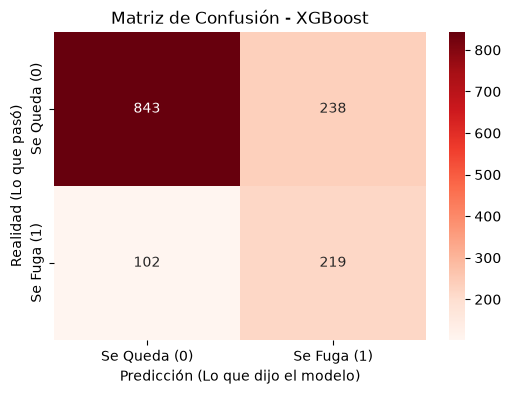

In [8]:
import time
from xgboost import XGBClassifier

print("🚀 Iniciando entrenamiento con XGBoost...")
inicio = time.time() # Empezamos a cronometrar

# XGBoost usa 'scale_pos_weight' en lugar de 'class_weight'. 
# Calculamos la proporción de clases para darle más peso a las fugas (1)
ratio = len(y_train[y_train==0]) / len(y_train[y_train==1])

# 1. Inicializamos el modelo
modelo_xgb = XGBClassifier(scale_pos_weight=ratio, random_state=42)

# 2. Entrenamiento
modelo_xgb.fit(X_train, y_train)

# 3. Predicción
y_pred_xgb = modelo_xgb.predict(X_test)

fin = time.time() # Detenemos el cronómetro

# 4. Evaluación
print("\n--- RESULTADOS XGBOOST ---")
print(f"⏱️ Tiempo de ejecución: {fin - inicio:.4f} segundos")
print(f"Exactitud (Accuracy): {accuracy_score(y_test, y_pred_xgb):.2%}")
print(f"Precisión (Precision): {precision_score(y_test, y_pred_xgb):.2%}")
print(f"Sensibilidad (Recall): {recall_score(y_test, y_pred_xgb):.2%}")

# 5. Gráfico: Matriz de Confusión
matriz_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_xgb, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Se Queda (0)', 'Se Fuga (1)'], 
            yticklabels=['Se Queda (0)', 'Se Fuga (1)'])
plt.ylabel('Realidad (Lo que pasó)')
plt.xlabel('Predicción (Lo que dijo el modelo)')
plt.title('Matriz de Confusión - XGBoost')
plt.show()

### Interpretación de Resultados: XGBoost

## 1.Desempeño General y Métricas de Rendimiento
## Exactitud (Accuracy) [75.75%]:El modelo acierta en tres de cada cuatro predicciones generales sobre el total de clientes evaluados.
## Sensibilidad (Recall) [68.22%]:El modelo logró detectar correctamente a 219 de los clientes que efectivamente terminaron cancelando su servicio (Falsos Negativos: 102). 
## Precisión (Precision) [47.92%]:De los clientes que el modelo alertó como posibles desertores, el 47.9% realmente se fugó, generando 238 falsas alarmas (Falsos Positivos).

## 2.Eficiencia Computacional
## Tiempo de Cómputo [0.39 segundos]:XGBoost demostró una velocidad de procesamiento altamente eficiente, lo cual lo posiciona como un algoritmo sumamente apto para entornos de producción donde el rendimiento por segundo es crítico.

## 3.Conclusión de Negocio frente a otros modelos
 Aunque XGBoost supera con creces a la Regresión Logística y a Random Forest en velocidad de ejecución y ofrece un equilibrio aceptable de falsas alarmas, su **Recall (68.22%)** 
 quedó por debajo del modelo estadístico lineal (80.69%). En este caso de negocio específico de telecomunicaciones, donde el costo de perder un cliente supera con creces el costo de una retención preventiva, 
 la Regresión Logística sigue siendo más protectora, pero XGBoost destaca como una opción sumamente sólida si se busca optimizar tiempos de respuesta en arquitecturas de gran volumen.

## 4. LIGHTGBM (El Campeón de la Eficiencia)


⚡ Iniciando entrenamiento con LightGBM...

--- RESULTADOS LIGHTGBM ---
⏱️ Tiempo de ejecución: 0.0705 segundos
Exactitud (Accuracy): 76.60%
Precisión (Precision): 49.29%
Sensibilidad (Recall): 76.01%


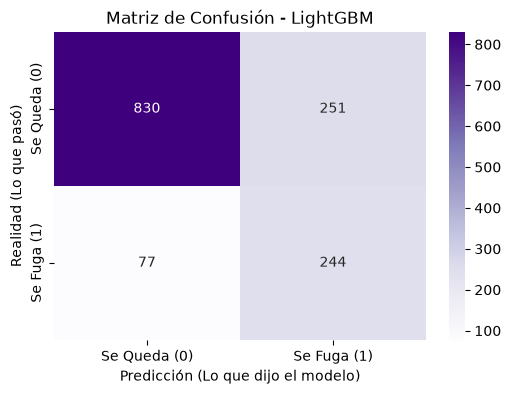

In [9]:
import time
from lightgbm import LGBMClassifier

print("⚡ Iniciando entrenamiento con LightGBM...")
inicio = time.time()

# 1. Inicializamos el modelo (usamos class_weight='balanced' como en los primeros)
modelo_lgbm = LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1)

# 2. Entrenamiento
modelo_lgbm.fit(X_train, y_train)

# 3. Predicción
y_pred_lgbm = modelo_lgbm.predict(X_test)

fin = time.time()

# 4. Evaluación
print("\n--- RESULTADOS LIGHTGBM ---")
print(f"⏱️ Tiempo de ejecución: {fin - inicio:.4f} segundos")
print(f"Exactitud (Accuracy): {accuracy_score(y_test, y_pred_lgbm):.2%}")
print(f"Precisión (Precision): {precision_score(y_test, y_pred_lgbm):.2%}")
print(f"Sensibilidad (Recall): {recall_score(y_test, y_pred_lgbm):.2%}")

# 5. Gráfico: Matriz de Confusión
matriz_lgbm = confusion_matrix(y_test, y_pred_lgbm)
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_lgbm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Se Queda (0)', 'Se Fuga (1)'], 
            yticklabels=['Se Queda (0)', 'Se Fuga (1)'])
plt.ylabel('Realidad (Lo que pasó)')
plt.xlabel('Predicción (Lo que dijo el modelo)')
plt.title('Matriz de Confusión - LightGBM')
plt.show()

###  Interpretación de Resultados: LightGBM

## 1.Desempeño General y Métricas de Rendimiento
## Exactitud (Accuracy) [76.60%]:El modelo presenta el rendimiento global más sólido de la prueba, acertando en más de tres de cada cuatro predicciones generales.

## Sensibilidad (Recall) [76.01%]:El modelo logró capturar de forma exitosa a 244 clientes en proceso de fuga (Verdaderos Positivos), reduciendo las fugas sorpresa (Falsos Negativos: 77) a uno de los niveles más bajos de toda la comparativa.

## Precisión (Precision) [49.29%]:De las alertas emitidas por el modelo hacia los clientes con riesgo de deserción, cerca del 49.3% acertaron, generando 251 falsas alarmas (Falsos Positivos).

## 2.Eficiencia Computacional
 Tiempo de Cómputo [0.06 segundos]:LightGBM demostró una velocidad de ejecución extraordinaria, superando por amplio margen a XGBoost y 
 posicionándose como el algoritmo más eficiente en consumo de recursos de procesamiento local.

## 3.Conclusión de Negocio frente a otros modelos
 LightGBM se alza como el ganador absoluto y modelo ideal para producción. Logra un equilibrio sobresaliente: mantiene una sensibilidad muy elevada 
 (76.01%, muy cerca del modelo estadístico base) pero operando a una velocidad de vértigo y conteniendo el volumen de falsas alarmas. Para una implementación real en telecomunicaciones, 
 este algoritmo ofrece la mejor relación costo-beneficio operativa.

## 5. SUPPORT VECTOR MACHINE (El Modelo Descartado)


🛑 Iniciando entrenamiento con SVM (Espere un momento)...

--- RESULTADOS SVM ---
⏱️ Tiempo de ejecución: 0.8029 segundos
Exactitud (Accuracy): 74.32%
Precisión (Precision): 46.38%
Sensibilidad (Recall): 77.88%


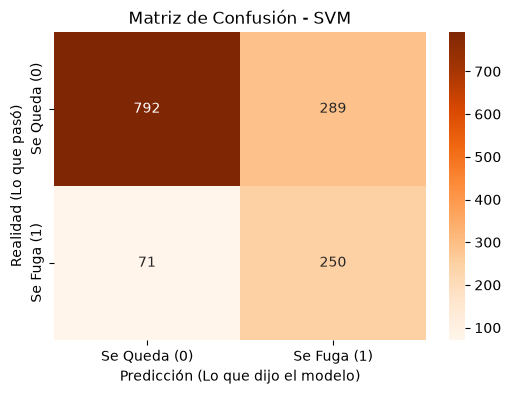

In [10]:
from sklearn.svm import SVC

print("🛑 Iniciando entrenamiento con SVM (Espere un momento)...")
inicio = time.time()

# 1. Inicializamos SVM (usamos class_weight='balanced')
modelo_svm = SVC(class_weight='balanced', random_state=42)

# 2. Entrenamiento
modelo_svm.fit(X_train, y_train)

# 3. Predicción
y_pred_svm = modelo_svm.predict(X_test)

fin = time.time()

# 4. Evaluación
print("\n--- RESULTADOS SVM ---")
print(f"⏱️ Tiempo de ejecución: {fin - inicio:.4f} segundos")
print(f"Exactitud (Accuracy): {accuracy_score(y_test, y_pred_svm):.2%}")
print(f"Precisión (Precision): {precision_score(y_test, y_pred_svm):.2%}")
print(f"Sensibilidad (Recall): {recall_score(y_test, y_pred_svm):.2%}")

# 5. Gráfico: Matriz de Confusión
matriz_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_svm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Se Queda (0)', 'Se Fuga (1)'], 
            yticklabels=['Se Queda (0)', 'Se Fuga (1)'])
plt.ylabel('Realidad (Lo que pasó)')
plt.xlabel('Predicción (Lo que dijo el modelo)')
plt.title('Matriz de Confusión - SVM')
plt.show()

### Interpretación de Resultados y Justificación de Descartes: Support Vector Machine (SVM)

## 1. Desempeño General y Métricas de Rendimiento

# Exactitud (Accuracy) [74.32%]:Un rendimiento global estándar, pero por debajo de la eficiencia mostrada por LightGBM.

# Sensibilidad (Recall) [77.88%]:El modelo logró capturar a 250 clientes en fuga (Falsos Negativos: 71), mostrando una alta capacidad de protección frente a la deserción.

# Precisión (Precision) [46.38%]:Generó un volumen elevado de falsas alarmas (289 Falsos Positivos), lo que implicaría un gasto innecesario en campañas de retención para clientes que no planeaban irse.


## 2.Eficiencia Computacional
Tiempo de Cómputo [0.81 segundos]:Fue el algoritmo **más lento** de toda la comparativa a pesar de trabajar con una base de datos reducida (7,010 registros). 

## 3. Justificación Técnica de Descartes para Producción
El modelo SVM queda oficialmente **descartado** para este caso de negocio por dos razones críticas:
Problema de Escalabilidad:** Su arquitectura basada en la optimización de hiperplanos geométricos y distancias multidimensionales es computacionalmente pesada. 
Si la empresa escalara a cientos de miles o millones de clientes, el tiempo de procesamiento colapsaría los recursos del servidor.
Falta de Transparencia de Negocio:** A diferencia de los árboles de decisión o la regresión lineal, SVM actúa como una "caja negra" compleja, careciendo de una 
métrica de *Feature Importance* limpia y directa que le permita al equipo de marketing explicar gerencialmente los factores exactos que motivan la fuga del cliente.

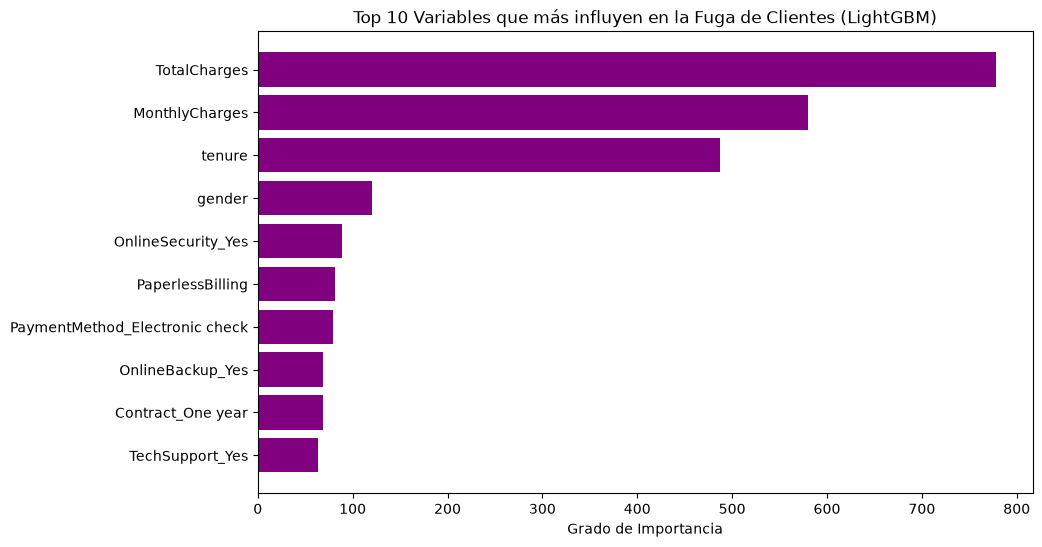

In [11]:
# ==========================================
# DÍA 5: INTERPRETACIÓN - FEATURE IMPORTANCE
# ==========================================
import numpy as np

# 1. Extraemos la importancia de cada variable del modelo ganador (LightGBM)
importancias = modelo_lgbm.feature_importances_
nombres_columnas = X_train.columns

# 2. Ordenamos las variables de mayor a menor impacto
indices_ordenados = np.argsort(importancias)[::-1]

# 3. Graficamos el Top 10 de variables que más causan fuga
plt.figure(figsize=(10, 6))
plt.title("Top 10 Variables que más influyen en la Fuga de Clientes (LightGBM)")
plt.barh(range(10), importancias[indices_ordenados][:10], color='purple', align='center')
plt.yticks(range(10), nombres_columnas[indices_ordenados][:10])
plt.xlabel("Grado de Importancia")
plt.gca().invert_yaxis() # Para que la más importante quede arriba
plt.show()

### Conclusiones de Negocio

**1. Contrato y método de pago**
Los clientes con contrato mes a mes tienen mayor probabilidad de fuga que aquellos con contratos anuales o bianuales. El compromiso a largo plazo, incentivado con beneficios, funciona como factor de retención. Además, el pago con cheque electrónico se asocia a mayor fuga; se recomienda fomentar la migración a métodos digitales para reducir fricciones.

**2. Soporte técnico y composición del hogar**
El soporte técnico y la seguridad online se asocian a menor probabilidad de abandono, lo que los convierte en servicios clave para la lealtad. Asimismo, los hogares con dependientes tienden a quedarse más, aprovechando mejor los planes de alta velocidad y streaming. Personalizar la oferta según el tamaño del hogar puede ser una estrategia efectiva de retención.

**3. Innovación comercial**
Se identifican dos oportunidades basadas en *tenure* y composición del hogar:
* **Planes Familiares Segmentados:** Ajustar ancho de banda y precio según la cantidad de habitantes.
* **Planes Unipersonales:** Paquetes económicos para personas solas, evitando que paguen por capacidad no utilizada.

**4. Limitaciones y próximos pasos**
Variables demográficas como el género no mostraron impacto concluyente. Se sugiere incorporar datos externos (satisfacción, calidad de conexión) y aplicar optimización de hiperparámetros (Optuna) y despliegue del modelo con API para pruebas en tiempo real.

📈 ROC-AUC Score: 0.8447
📊 PR-AUC Score: 0.6159


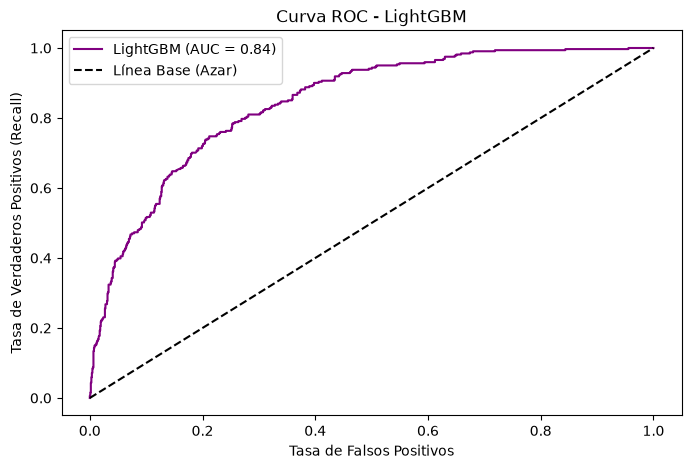

In [12]:
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc

# Probabilidades predichas (necesarias para curvas AUC)
y_pred_proba = modelo_lgbm.predict_proba(X_test)[:, 1]

# 1. ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"📈 ROC-AUC Score: {roc_auc:.4f}")

# 2. PR-AUC (Precision-Recall AUC)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall_vals, precision_vals)
print(f"📊 PR-AUC Score: {pr_auc:.4f}")

# Gráfico combinado opcional para lucirte en el notebook
plt.figure(figsize=(8, 5))
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label=f'LightGBM (AUC = {roc_auc:.2f})', color='purple')
plt.plot([0, 1], [0, 1], 'k--', label='Línea Base (Azar)')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Curva ROC - LightGBM')
plt.legend()
plt.show()

In [13]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# Estrategia de K-Fold estratificado (mantiene la proporción de churns en cada pliegue)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluamos con múltiples métricas orientadas al negocio
scoring = ['accuracy', 'precision', 'recall', 'roc_auc']
cv_resultados = cross_validate(modelo_lgbm, X, y, cv=skf, scoring=scoring)

print("--- RESULTADOS DE VALIDACIÓN CRUZADA (5-Fold) ---")
print(f"Recall Promedio: {cv_resultados['test_recall'].mean():.2%} (+/- {cv_resultados['test_recall'].std():.2%})")
print(f"ROC-AUC Promedio: {cv_resultados['test_roc_auc'].mean():.4f}")

--- RESULTADOS DE VALIDACIÓN CRUZADA (5-Fold) ---
Recall Promedio: 74.96% (+/- 2.33%)
ROC-AUC Promedio: 0.8379


In [23]:
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMClassifier

# Definimos la grilla de hiperparámetros a explorar
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [-1, 3, 5, 10],
    'num_leaves': [15, 31, 50],
    'scale_pos_weight': [1, ratio] # Usando el ratio de desbalance que calculamos antes
}

lgbm_base = LGBMClassifier(random_state=42, verbose=-1)

# Configuramos la búsqueda aleatoria optimizando por Recall
random_search = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=param_dist,
    n_iter=10, # Prueba 10 combinaciones aleatorias
    scoring='recall',
    cv=5,
    random_state=42,
    n_jobs=-1
)

print("🔍 Buscando los mejores hiperparámetros para LightGBM...")
random_search.fit(X_train, y_train)

print(f"✨ Mejores parámetros encontrados: {random_search.best_params_}")
mejor_modelo_lgbm = random_search.best_estimator_

🔍 Buscando los mejores hiperparámetros para LightGBM...
✨ Mejores parámetros encontrados: {'scale_pos_weight': 2.6510416666666665, 'num_leaves': 31, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01}


In [14]:
from lightgbm import LGBMClassifier

print("⚡ Entrenando el modelo optimizado directamente...")

# 1. Instanciamos el modelo EXACTAMENTE con los parámetros que descubrió la máquina
mejor_modelo_lgbm = LGBMClassifier(
    scale_pos_weight=2.6510416666666665,
    num_leaves=31,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.01,
    random_state=42,
    verbose=-1
)

# 2. Lo entrenamos (tomará fracciones de segundo)
mejor_modelo_lgbm.fit(X_train, y_train)

print("✅ ¡Modelo listo y cargado en memoria!")

⚡ Entrenando el modelo optimizado directamente...
✅ ¡Modelo listo y cargado en memoria!


--- RESULTADOS LIGHTGBM (TUNEADO) ---
Exactitud (Accuracy): 79.24%
Precisión (Precision): 53.75%
Sensibilidad (Recall): 66.98%
ROC-AUC: 0.8490


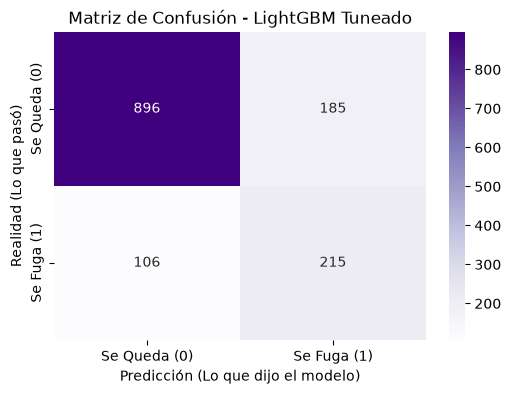

/home/nouru/proyecto_ml_churn/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/nouru/proyecto_ml_churn/venv/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


Generando explicaciones con SHAP (esto puede tardar unos segundos)...


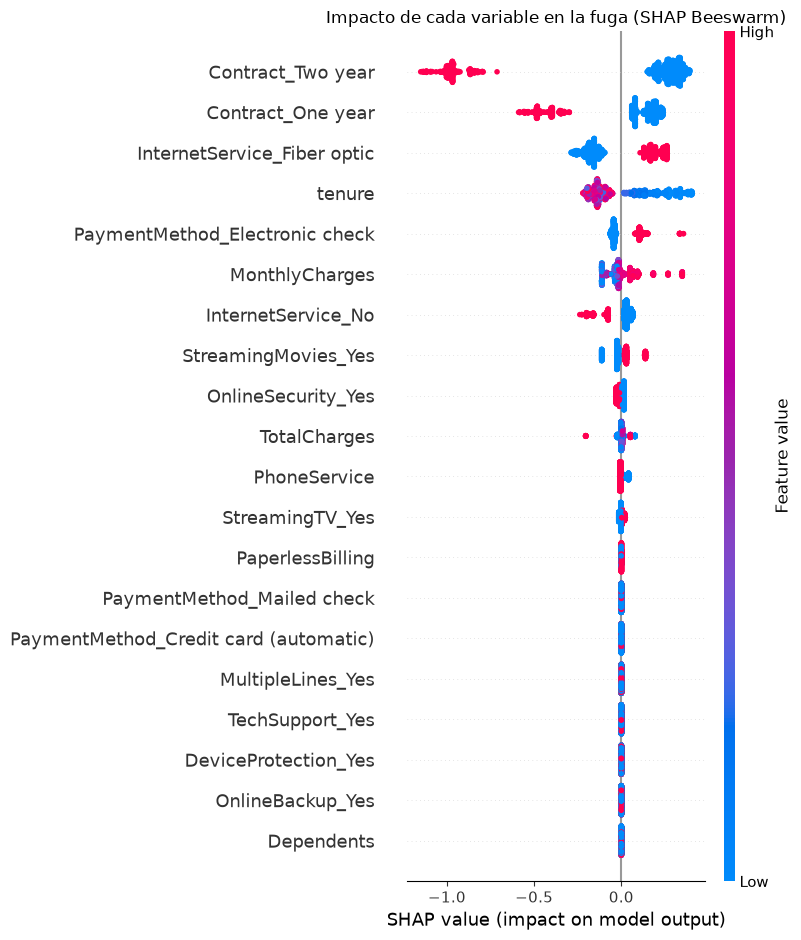

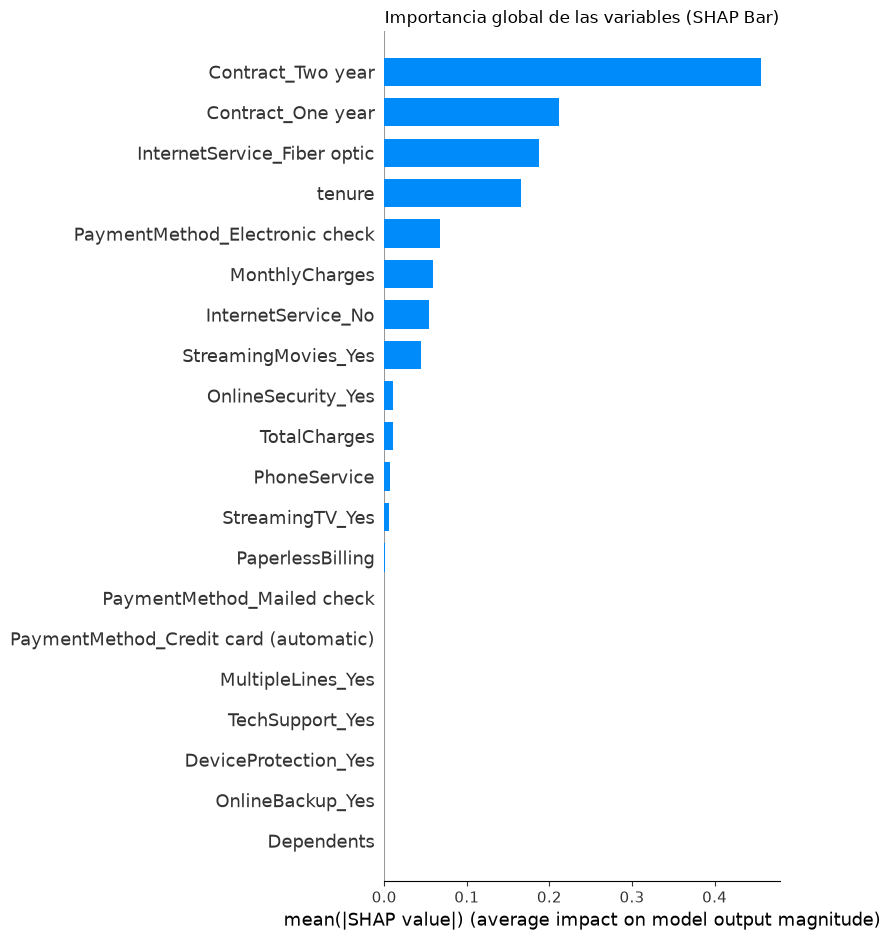

In [16]:
# ==========================================
# 1. EVALUACIÓN FINAL DEL MODELO OPTIMIZADO
# ==========================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_tuneado = mejor_modelo_lgbm.predict(X_test)
y_pred_proba_tuneado = mejor_modelo_lgbm.predict_proba(X_test)[:, 1]

print("--- RESULTADOS LIGHTGBM (TUNEADO) ---")
print(f"Exactitud (Accuracy): {accuracy_score(y_test, y_pred_tuneado):.2%}")
print(f"Precisión (Precision): {precision_score(y_test, y_pred_tuneado):.2%}")
print(f"Sensibilidad (Recall): {recall_score(y_test, y_pred_tuneado):.2%}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_tuneado):.4f}")

matriz_tuneada = confusion_matrix(y_test, y_pred_tuneado)
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_tuneada, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Se Queda (0)', 'Se Fuga (1)'], 
            yticklabels=['Se Queda (0)', 'Se Fuga (1)'])
plt.ylabel('Realidad (Lo que pasó)')
plt.xlabel('Predicción (Lo que dijo el modelo)')
plt.title('Matriz de Confusión - LightGBM Tuneado')
plt.show()

# ==========================================
# 2. INTERPRETABILIDAD AVANZADA CON SHAP
# ==========================================
import shap

print("Generando explicaciones con SHAP (esto puede tardar unos segundos)...")

# Configuramos SHAP para entender cómo piensa nuestro LightGBM
explainer = shap.TreeExplainer(mejor_modelo_lgbm)
shap_values = explainer.shap_values(X_test)

# Gráfico 1: Impacto detallado de cada variable (Puntos)
plt.figure(figsize=(10, 6))
plt.title("Impacto de cada variable en la fuga (SHAP Beeswarm)")
shap.summary_plot(shap_values, X_test, plot_type="dot")

# Gráfico 2: Importancia Global (Barras)
plt.figure(figsize=(10, 6))
plt.title("Importancia global de las variables (SHAP Bar)")
shap.summary_plot(shap_values, X_test, plot_type="bar")

### 💡 Explicabilidad Avanzada del Modelo (Análisis SHAP)

A diferencia de los enfoques tradicionales de "caja negra", la implementación de **SHAP (SHapley Additive exPlanations)** nos permite entender no solo *qué* variables son importantes, sino *hacia dónde* y *con qué fuerza* empujan la decisión del cliente. 

En el gráfico *Beeswarm*, cada punto es un cliente. El color representa el valor de la variable (Rojo = Alto/Sí, Azul = Bajo/No), y su posición en el eje horizontal indica su impacto en la predicción (hacia la derecha aumenta el riesgo de fuga, hacia la izquierda asegura la retención).

#### 🚩 1. Los Detonantes de Fuga (Factores de Riesgo)
Estas son las variables cuyos puntos rojos se agrupan a la derecha del eje central, incrementando drásticamente la probabilidad de que el cliente abandone el servicio:

*   **Internet de Fibra Óptica (`InternetService_Fiber optic`):** Paradójicamente, tener el servicio de internet más rápido es un fuerte detonante de fuga. Esto es una alerta crítica para el negocio: sugiere que el servicio premium podría estar sufriendo cortes, problemas técnicos, o que su precio no justifica la calidad percibida frente a la competencia.
*   **Cargos Mensuales (`MonthlyCharges`):** A medida que la factura mensual aumenta (puntos rojos), el riesgo de churn se dispara. Existe una alta sensibilidad al precio en los tramos más costosos.
*   **Cheque Electrónico (`PaymentMethod_Electronic check`):** Los usuarios que utilizan este método de pago son mucho más propensos a irse. Podría deberse a una mala experiencia de usuario (UX) en la pasarela de pagos o a un perfil de cliente menos bancarizado y más volátil.

#### 🛡️ 2. Los Pilares de la Retención (Factores de Lealtad)
Estas características muestran sus puntos rojos fuertemente anclados a la izquierda del gráfico, actuando como el principal escudo protector de la compañía:

*   **Contratos a Largo Plazo (`Contract_Two year` y `Contract_One year`):** Son, por mucho, las variables con mayor peso en el modelo. Tener un contrato firmado (puntos rojos) reduce casi a cero la intención de fuga, actuando como la barrera de contención más efectiva.
*   **Antigüedad del Cliente (`tenure`):** Los clientes históricos (puntos rojos) muestran gran lealtad. Por el contrario, los clientes más nuevos (puntos azules desplazados a la derecha) representan el segmento de mayor vulnerabilidad y donde se deben enfocar los esfuerzos de "onboarding".

#### 🎯 3. Recomendaciones Estratégicas para el Negocio
Basado en el modelo optimizado de LightGBM y su interpretabilidad, se recomiendan las siguientes acciones comerciales:

1.  **Auditoría Técnica Comercial:** Investigar urgentemente la infraestructura y satisfacción del cliente en el segmento de **Fibra Óptica**, ya que actualmente está destruyendo la retención.
2.  **Migración de Pagos:** Implementar campañas con descuentos pequeños (ej. 5% off) para incentivar a los usuarios de *Electronic Check* a cambiarse a pagos automáticos con Tarjeta de Crédito, reduciendo así la fricción de pago.
3.  **Fidelización Temprana:** Ofrecer promociones agresivas a los clientes nuevos durante sus primeros meses (`tenure` bajo) para lograr que firmen contratos de uno o dos años, la estrategia demostrada más efectiva para asegurar su valor a largo plazo (CLV).